# Lab 04 - Assignment 2

In [16]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate

In [17]:
def compute_moments(img):
    M, N = img.shape
    moments = {}
    
    for p in range(4):
        for q in range(4):
            if p + q <= 3:
                moment = 0
                for x in range(M):
                    for y in range(N):
                        moment += (x ** p) * (y ** q) * img[x, y]
                moments[f'm_{p}{q}'] = moment
    
    return moments

In [18]:
def compute_central_moments(img, moments):
    M, N = img.shape

    x_bar = moments['m_10'] / moments['m_00'] if moments['m_00'] != 0 else 0
    y_bar = moments['m_01'] / moments['m_00'] if moments['m_00'] != 0 else 0
    
    central_moments = {}
    
    for p in range(4):
        for q in range(4):
            if p + q <= 3:
                mu = 0
                for x in range(M):
                    for y in range(N):
                        mu += ((x - x_bar) ** p) * ((y - y_bar) ** q) * img[x, y]
                central_moments[f'mu_{p}{q}'] = mu
    
    return central_moments, x_bar, y_bar


In [19]:
def compute_normalized_central_moments(central_moments):
    normalized = {}
    mu_00 = central_moments['mu_00']
    
    for p in range(4):
        for q in range(4):
            if p + q >= 2 and p + q <= 3:
                gamma = (p + q) / 2 + 1
                key = f'eta_{p}{q}'
                mu_key = f'mu_{p}{q}'
                normalized[key] = central_moments[mu_key] / (mu_00 ** gamma) if mu_00 != 0 else 0
    
    return normalized


In [20]:
def compute_hu_moments(eta):
    n20 = eta.get('eta_20', 0)
    n02 = eta.get('eta_02', 0)
    n11 = eta.get('eta_11', 0)
    n30 = eta.get('eta_30', 0)
    n12 = eta.get('eta_12', 0)
    n21 = eta.get('eta_21', 0)
    n03 = eta.get('eta_03', 0)
    
    phi1 = n20 + n02
    
    phi2 = (n20 - n02)**2 + 4 * n11**2
    
    phi3 = (n30 - 3*n12)**2 + (3*n21 - n03)**2
    
    phi4 = (n30 + n12)**2 + (n21 + n03)**2
    
    phi5 = ((n30 - 3*n12) * (n30 + n12) *  ((n30 + n12)**2 - 3*(n21 + n03)**2) + (3*n21 - n03) * (n21 + n03) *  (3*(n30 + n12)**2 - (n21 + n03)**2))
    
    phi6 = ((n20 - n02) * ((n30 + n12)**2 - (n21 + n03)**2) + 4*n11 * (n30 + n12) * (n21 + n03))
    
    phi7 = ((3*n21 - n03) * (n30 + n12) *  ((n30 + n12)**2 - 3*(n21 + n03)**2) + (3*n21 - n30) * (n21 + n03) *  (3*(n30 + n12)**2 - (n21 + n03)**2))
    
    return [phi1, phi2, phi3, phi4, phi5, phi6, phi7]

In [21]:
def get_hu_moments(img):
    img_normalized = img.astype(np.float64) / 255.0
    
    moments = compute_moments(img_normalized)
    central_moments, x_bar, y_bar = compute_central_moments(img_normalized, moments)
    normalized_moments = compute_normalized_central_moments(central_moments)
    hu_moments = compute_hu_moments(normalized_moments)
    
    return hu_moments[:4]


In [22]:
def chi_squared_distance(features1, features2):
    features1 = np.array(features1)
    features2 = np.array(features2)
    
    distance = 0
    for i in range(len(features1)):
        denominator = features1[i] + features2[i]
        if denominator != 0:
            distance += ((features1[i] - features2[i]) ** 2) / denominator
    
    return 0.5 * distance

In [23]:
def apply_transformations(img):
    h, w = img.shape
    center = (w // 2, h // 2)
    
    transformations = {}
    transformations['Original'] = img.copy()
    
    M_rot = cv2.getRotationMatrix2D(center, 45, 1.0)
    transformations['Rotated 45°'] = cv2.warpAffine(img, M_rot, (w, h))
    
    transformations['Scaled 0.5x'] = cv2.resize(img, None, fx=0.5, fy=0.5)
    transformations['Scaled 0.5x'] = cv2.resize(transformations['Scaled 0.5x'], (w, h))
    
    transformations['Mirrored'] = cv2.flip(img, 1)

    alpha = 1.5  # Contrast control
    beta = 10    # Brightness control
    transformations['Contrast Enhanced'] = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
    
    M_rot_scale = cv2.getRotationMatrix2D(center, 30, 0.8)
    transformations['Rotated 30° + Scaled'] = cv2.warpAffine(img, M_rot_scale, (w, h))
    
    return transformations

## Load Original image in Grayscale

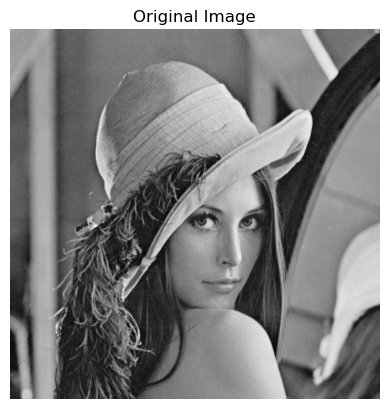

In [24]:
img = cv2.imread('../../../assets/Lena.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

## Testing on 5x5 Patch

Extract a small 5x5 patch from the base image and analyze its Hu moments under various transformations.


Extracted 5x5 patch from center of base image
Patch location: (256, 256) to (261, 261)

Patch values:
[[101  99 103 101  73]
 [ 72  74  85  84  64]
 [ 56  54  62  62  57]
 [ 56  50  52  51  56]
 [ 52  51  55  52  56]]


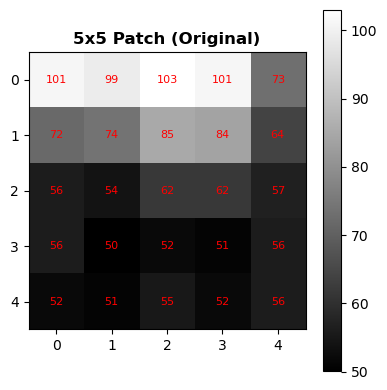

In [25]:
h, w = img.shape
patch_size = 5
ch, cw = h // 2, w // 2
patch = img[ch:ch+patch_size, cw:cw+patch_size]

print(f"\nExtracted {patch_size}x{patch_size} patch from center of base image")
print(f"Patch location: ({ch}, {cw}) to ({ch+patch_size}, {cw+patch_size})")
print("\nPatch values:")
print(patch)

fig_patch, ax_patch = plt.subplots(1, 1, figsize=(4, 4))
im = ax_patch.imshow(patch, cmap='gray', interpolation='nearest')
ax_patch.set_title('5x5 Patch (Original)', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax_patch)
for i in range(patch_size):
    for j in range(patch_size):
        ax_patch.text(j, i, patch[i, j], ha="center", va="center", color="red", fontsize=8)
plt.tight_layout()
plt.show()

## Apply Transformations to Patch

In [26]:
patch_transforms = apply_transformations(patch)

patch_base_hu = get_hu_moments(patch)

print("\nBase Patch Hu Moments:")
print(f"  phi1 = {patch_base_hu[0]:.6f}")
print(f"  phi2 = {patch_base_hu[1]:.6f}")
print(f"  phi3 = {patch_base_hu[2]:.6f}")
print(f"  phi4 = {patch_base_hu[3]:.6f}")


Base Patch Hu Moments:
  phi1 = 0.606221
  phi2 = 0.000788
  phi3 = 0.001373
  phi4 = 0.003699


### Patch Hu Moments Table

In [ ]:
patch_hu_table = []
patch_labels = []

for trans_name, trans_patch in patch_transforms.items():
    hu = get_hu_moments(trans_patch)
    dist = chi_squared_distance(patch_base_hu, hu)
    patch_hu_table.append([trans_name] + [f"{val:.6f}" for val in hu] + [f"{dist:.6f}"])
    patch_labels.append(trans_name)

print("\nPatch Hu Moments and Chi-Squared Distances:")
headers = ['Transformation', 'phi1', 'phi2', 'phi3', 'phi4', 'chi² Distance']
print(tabulate(patch_hu_table, headers=headers, tablefmt='grid'))

print("\nInvariance Analysis:")
for row in patch_hu_table:
    if float(row[-1]) < 0.0001:
        print(f"  {row[0]}: PERFECTLY INVARIANT (chi^2 ≈ 0)")
    elif float(row[-1]) < 0.01:
        print(f"  {row[0]}: Nearly invariant (chi^2 = {row[-1]})")
    else:
        print(f"  {row[0]}: Significant change (chi^2 = {row[-1]})")


Patch Hu Moments and Chi-Squared Distances:
+----------------------+----------+----------+----------+----------+-----------------+
| Transformation       |     phi1 |     phi2 |     phi3 |     phi4 |   chi² Distance |
+======================+==========+==========+==========+==========+=================+
| Original             | 0.606221 | 0.000788 | 0.001373 | 0.003699 |        0        |
+----------------------+----------+----------+----------+----------+-----------------+
| Rotated 45°          | 0.610797 | 0.001105 | 8.3e-05  | 0.003425 |        0.000612 |
+----------------------+----------+----------+----------+----------+-----------------+
| Scaled 0.5x          | 0.55129  | 0.000108 | 0.001429 | 0.001469 |        0.002043 |
+----------------------+----------+----------+----------+----------+-----------------+
| Mirrored             | 0.606221 | 0.000788 | 0.001373 | 0.003699 |        0        |
+----------------------+----------+----------+----------+----------+-----------------

### Visualize Patch Transformations

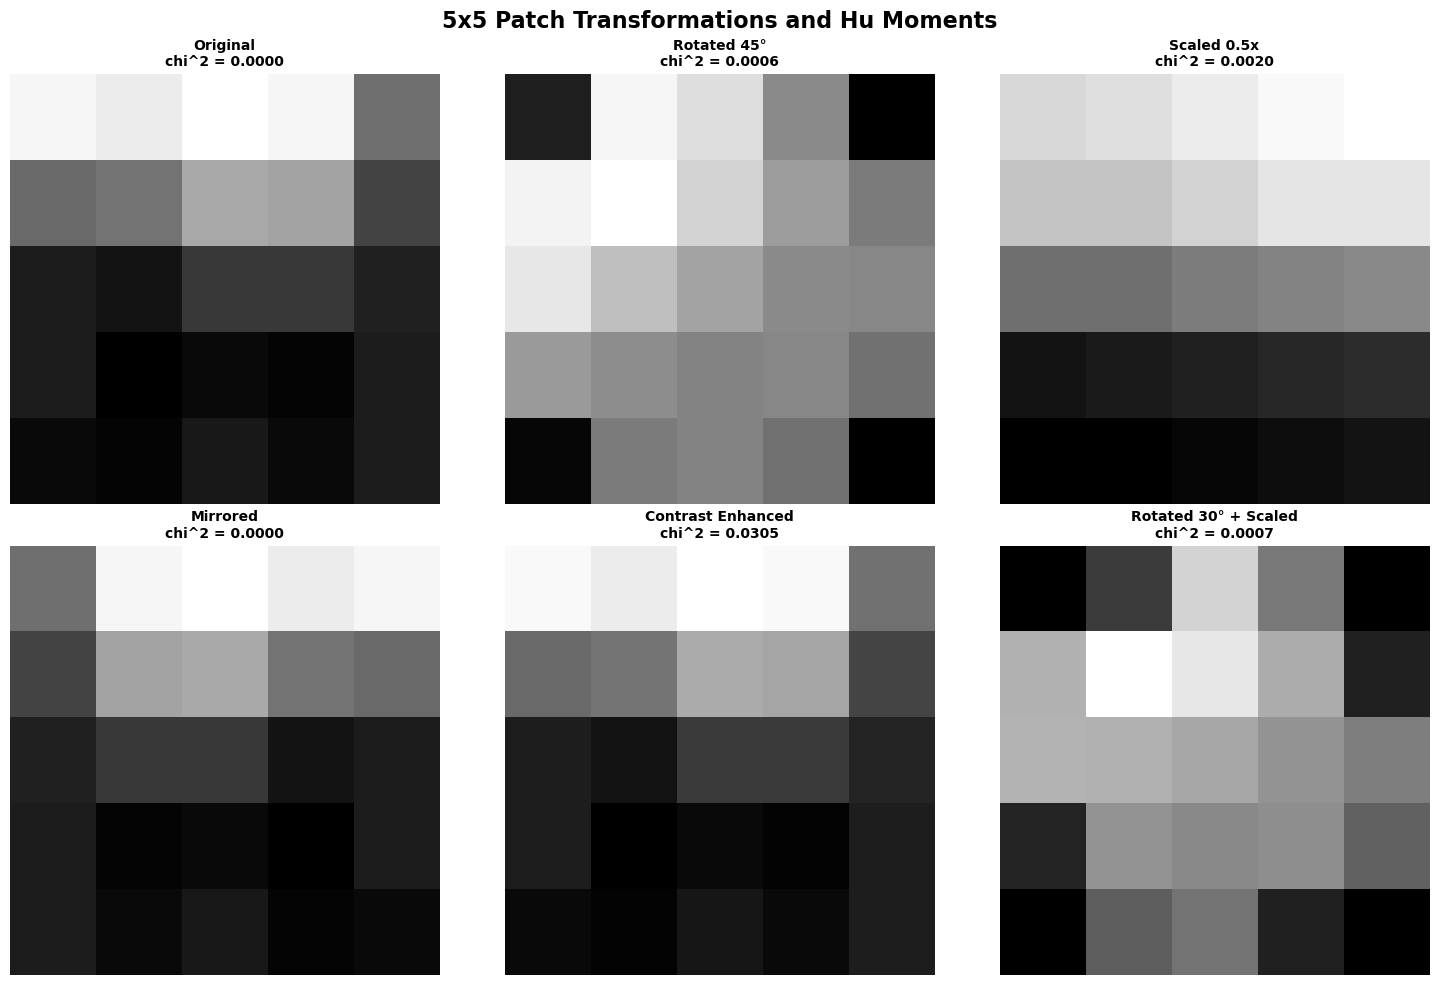

In [28]:
fig4, axes = plt.subplots(2, 3, figsize=(15, 10))
fig4.suptitle('5x5 Patch Transformations and Hu Moments', fontsize=16, fontweight='bold')

patch_trans_list = list(patch_transforms.items())
for idx, (trans_name, trans_patch) in enumerate(patch_trans_list[:6]):
    ax = axes[idx // 3, idx % 3]
    
    display_patch = cv2.resize(trans_patch, (100, 100), interpolation=cv2.INTER_NEAREST)
    ax.imshow(display_patch, cmap='gray')
    
    hu = get_hu_moments(trans_patch)
    dist = chi_squared_distance(patch_base_hu, hu)
    
    if dist < 0.0001:
        border_color = 'green'
        border_width = 3
    elif dist < 0.01:
        border_color = 'orange'
        border_width = 2
    else:
        border_color = 'red'
        border_width = 2
    
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(border_width)
    
    title = f"{trans_name}\nchi^2 = {dist:.4f}"
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()